In [1]:
!pip install numpy cupy-cuda12x opencv-python-headless matplotlib
import numpy as np
import cupy as cp
import cv2
import matplotlib.pyplot as plt
from numba import cuda

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 133.5/133.5 MB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.7/51.7 kB 5.1 MB/s eta 0:00:00


--- Task 3: DS5 Batch Gaussian Blur via CUDA ---
Fetching CIFAR-10 Dataset...
170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 14s 0us/step
Launching batch execution for 5 images...


/usr/local/lib/python3.12/dist-packages/numba_cuda/numba/cuda/dispatcher.py:696: NumbaPerformanceWarning: Grid size 20 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))


Displaying image grid visualization...


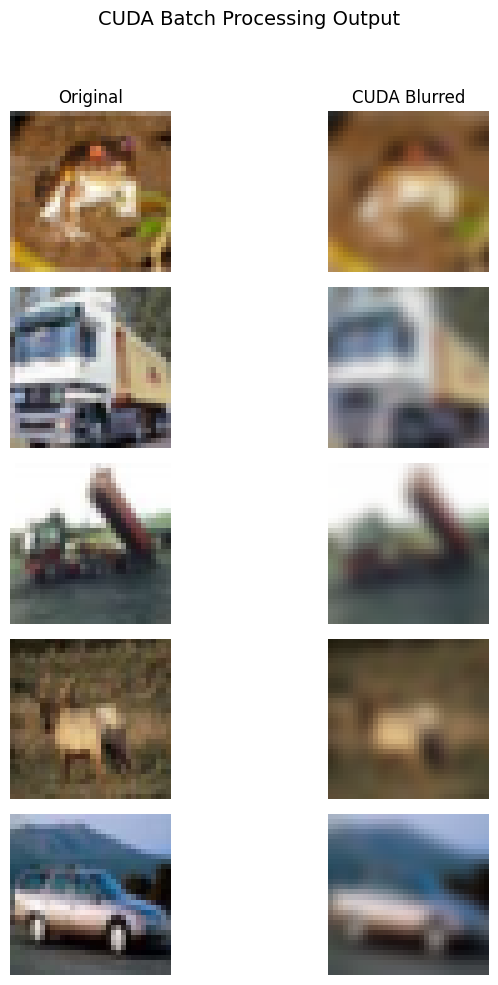

In [1]:
# task3_cifar_blur.py
import numpy as np
import cv2
import matplotlib.pyplot as plt
import tensorflow as tf
from numba import cuda

# Define BATCH 2D Convolution CUDA Kernel
@cuda.jit
def gaussian_blur_batch_kernel(d_img_batch, d_kernel, d_out_batch):
    n, x, y = cuda.grid(3) # Mapping to (Image_Index, Height, Width)

    num_imgs, height, width, channels = d_img_batch.shape
    k_size = d_kernel.shape[0]
    half_k = k_size // 2

    if n < num_imgs and x < height and y < width:
        for c in range(channels):
            pixel_sum = 0.0
            for ki in range(k_size):
                for kj in range(k_size):
                    # Clamp edge boundaries
                    img_x = min(max(x + ki - half_k, 0), height - 1)
                    img_y = min(max(y + kj - half_k, 0), width - 1)

                    pixel_sum += d_img_batch[n, img_x, img_y, c] * d_kernel[ki, kj]

            d_out_batch[n, x, y, c] = pixel_sum

def run_task3():
    print("--- Task 3: DS5 Batch Gaussian Blur via CUDA ---")

    # 1. Fetch CIFAR-10 Dataset
    print("Fetching CIFAR-10 Dataset...")
    (cifar_train, _), _ = tf.keras.datasets.cifar10.load_data()

    # Batch configuration (Change this to process more images)
    num_images = 5
    raw_images_batch = cifar_train[:num_images].astype(np.float32) / 255.0
    input_images_batch = np.ascontiguousarray(raw_images_batch)

    # 2. Define a 5x5 Gaussian Kernel Matrix
    gaussian_1d = cv2.getGaussianKernel(5, 1.5)
    gaussian_2d = np.outer(gaussian_1d, gaussian_1d).astype(np.float32)
    gaussian_2d = np.ascontiguousarray(gaussian_2d)

    # 3. Memory Allocation
    d_img_batch = cuda.to_device(input_images_batch)
    d_kernel = cuda.to_device(gaussian_2d)
    d_out_batch = cuda.device_array_like(input_images_batch)

    # 4. Configure Threads and Blocks (3D Grid mapping)
    threads_per_block_3d = (1, 16, 16)
    blocks_per_grid_3d = (
        (input_images_batch.shape[0] + threads_per_block_3d[0] - 1) // threads_per_block_3d[0],
        (input_images_batch.shape[1] + threads_per_block_3d[1] - 1) // threads_per_block_3d[1],
        (input_images_batch.shape[2] + threads_per_block_3d[2] - 1) // threads_per_block_3d[2]
    )

    # 5. Launch Kernel
    print(f"Launching batch execution for {num_images} images...")
    gaussian_blur_batch_kernel[blocks_per_grid_3d, threads_per_block_3d](d_img_batch, d_kernel, d_out_batch)
    cuda.synchronize()

    # 6. Gather Results and Visualize
    blurred_images_batch = d_out_batch.copy_to_host()
    processed_images = np.clip(blurred_images_batch, 0, 1)

    fig, axes = plt.subplots(num_images, 2, figsize=(8, 2 * num_images))
    fig.suptitle(f"CUDA Batch Processing Output", fontsize=14)

    for i in range(num_images):
        axes[i, 0].imshow(input_images_batch[i])
        axes[i, 0].axis('off')
        if i == 0: axes[i, 0].set_title("Original")

        axes[i, 1].imshow(processed_images[i])
        axes[i, 1].axis('off')
        if i == 0: axes[i, 1].set_title("CUDA Blurred")

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    print("Displaying image grid visualization...")
    plt.show()

if __name__ == "__main__":
    run_task3()